# Milestone Optimization for Brand Campaigns
 

## 1. Import Libraries & Set Up Environment


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

np.random.seed(42)
print("Environment setup complete.")



Environment setup complete.


## 2. Load Datasets


In [2]:
required_files = ["campaigns.csv", "creators.csv", "posts.csv", "historical_ladders.csv"]
missing = [f for f in required_files if not os.path.exists(f)]
if missing:
    print("Files missing. Creating realistic sample datasets...")
    
    categories = ["Fashion", "Gaming", "Tech", "Beauty", "Fitness", "Food"]
    tiers = ["Nano", "Micro", "Mid", "Macro"]
    
    # 1. Campaigns
    c_ids = [f"CMP_{i:03d}" for i in range(1, 51)]
    campaigns = pd.DataFrame({
        "campaign_id": c_ids,
        "category": np.random.choice(categories, 50, p=[0.25, 0.25, 0.20, 0.15, 0.10, 0.05]),
        "target_creator_tier": np.random.choice(tiers, 50, p=[0.20, 0.45, 0.25, 0.10]),
        "total_budget": np.random.choice([15000, 25000, 50000, 75000, 100000, 150000], 50),
        "start_date": pd.date_range("2024-01-01", periods=50, freq="D").strftime("%Y-%m-%d"),
        "end_date": pd.date_range("2024-02-01", periods=50, freq="D").strftime("%Y-%m-%d")
    })
    campaigns.to_csv("campaigns.csv", index=False)
    
    # 2. Creators
    cr_ids = [f"CR_{i:03d}" for i in range(1, 121)]
    cr_tiers = np.random.choice(tiers, 120, p=[0.30, 0.45, 0.15, 0.10])
    tier_base = {"Nano": 3000, "Micro": 15000, "Mid": 75000, "Macro": 350000}
    avg_views = [max(int(np.random.normal(tier_base[t], tier_base[t] * 0.25)), 500) for t in cr_tiers]
    
    creators = pd.DataFrame({
        "creator_id": cr_ids,
        "tier": cr_tiers,
        "historical_avg_views_per_post": avg_views
    })
    creators.to_csv("creators.csv", index=False)
    
    # 3. Posts
    n_posts = 350
    post_c = np.random.choice(c_ids, n_posts)
    post_cr = np.random.choice(cr_ids, n_posts)
    cr_map = dict(zip(creators["creator_id"], creators["tier"]))
    mu_map = {"Nano": 8.0, "Micro": 9.5, "Mid": 11.0, "Macro": 12.5}
    
    finals = [max(int(np.random.lognormal(mu_map[cr_map[cr]], 0.6)), 200) for cr in post_cr]
    posts = pd.DataFrame({
        "post_id": [f"P_{i:04d}" for i in range(1, n_posts + 1)],
        "campaign_id": post_c,
        "creator_id": post_cr,
        "post_date": pd.date_range("2024-01-10", periods=n_posts, freq="h").strftime("%Y-%m-%d %H:%M:%S"),
        "views_at_24h": [int(v * np.random.uniform(0.35, 0.50)) for v in finals],
        "views_at_7d": [int(v * np.random.uniform(0.70, 0.85)) for v in finals],
        "views_at_30d": [int(v * np.random.uniform(0.90, 0.98)) for v in finals],
        "views_final": finals,
        "total_payout_earned": [int(v * 0.05 + np.random.uniform(100, 500)) for v in finals]
    })
    posts.to_csv("posts.csv", index=False)
    
    # 4. Historical Ladders
    ladders = []
    for cid in c_ids:
        row = campaigns[campaigns["campaign_id"] == cid].iloc[0]
        budget = row["total_budget"]
        t_base = tier_base[row["target_creator_tier"]]
        mults = [0.3, 0.7, 1.2, 2.0, 3.2]
        payouts = [0.10, 0.15, 0.20, 0.25, 0.30]
        for rank in range(1, 6):
            ladders.append({
                "campaign_id": cid,
                "milestone_rank": rank,
                "view_threshold": int(t_base * mults[rank - 1]),
                "payout_amount": int(budget * payouts[rank - 1])
            })
    historical_ladders = pd.DataFrame(ladders)
    historical_ladders.to_csv("historical_ladders.csv", index=False)
    print("Sample datasets created successfully.")
# Load CSV files
campaigns = pd.read_csv("campaigns.csv")
creators = pd.read_csv("creators.csv")
posts = pd.read_csv("posts.csv")
historical_ladders = pd.read_csv("historical_ladders.csv")
print("Campaigns shape        :", campaigns.shape)
print("Creators shape         :", creators.shape)
print("Posts shape            :", posts.shape)
print("Historical Ladders shape:", historical_ladders.shape)

Campaigns shape        : (50, 6)
Creators shape         : (120, 3)
Posts shape            : (350, 11)
Historical Ladders shape: (250, 4)


## 3. Data Cleaning & Inspection


In [3]:
datasets = {
    "Campaigns": campaigns,
    "Creators": creators,
    "Posts": posts,
    "Historical Ladders": historical_ladders
}

for name, df in datasets.items():
    print("-" * 40)
    print(name)
    print("-" * 40)
    display(df.head())
    print("Null count:")
    print(df.isnull().sum())
    print()

campaigns["start_date"] = pd.to_datetime(campaigns["start_date"], errors="coerce")
campaigns["end_date"] = pd.to_datetime(campaigns["end_date"], errors="coerce")
posts["post_date"] = pd.to_datetime(posts["post_date"], errors="coerce")

posts.drop(columns=["historical_avg_views_per_post", "historical_completion_rate"], errors="ignore", inplace=True)


----------------------------------------
Campaigns
----------------------------------------


,campaign_id,category,target_creator_tier,total_budget,start_date,end_date
0,CMP_001,Gaming,Macro,15000,2024-01-01,2024-02-01
1,CMP_002,Food,Mid,75000,2024-01-02,2024-02-02
2,CMP_003,Beauty,Macro,100000,2024-01-03,2024-02-03
3,CMP_004,Tech,Mid,75000,2024-01-04,2024-02-04
4,CMP_005,Fashion,Micro,150000,2024-01-05,2024-02-05


Null count:
campaign_id            0
category               0
target_creator_tier    0
total_budget           0
start_date             0
end_date               0
dtype: int64

----------------------------------------
Creators
----------------------------------------


,creator_id,tier,historical_avg_views_per_post
0,CR_001,Nano,2665
1,CR_002,Micro,18211
2,CR_003,Macro,368733
3,CR_004,Micro,10328
4,CR_005,Micro,15649


Null count:
creator_id                       0
tier                             0
historical_avg_views_per_post    0
dtype: int64

----------------------------------------
Posts
----------------------------------------


,post_id,campaign_id,creator_id,post_date,views_at_24h,views_at_7d,views_at_30d,views_final,total_payout_earned,historical_avg_views_per_post,historical_completion_rate
0,P_0001,CMP_037,CR_028,2024-01-10 00:00:00,4006,7955,10615,10964,936,Micro,0.800090
1,P_0002,CMP_012,CR_087,2024-01-10 01:00:00,4389,7671,9249,10075,948,Micro,0.870489
2,P_0003,CMP_049,CR_078,2024-01-10 02:00:00,825,1787,2177,2341,217,Nano,0.851907
3,P_0004,CMP_013,CR_088,2024-01-10 03:00:00,19547,38102,43363,46282,2701,Mid,0.744713
4,P_0005,CMP_023,CR_002,2024-01-10 04:00:00,3836,7041,9437,10056,934,Micro,0.544940


Null count:
post_id                          0
campaign_id                      0
creator_id                       0
post_date                        0
views_at_24h                     0
views_at_7d                      0
views_at_30d                     0
views_final                      0
total_payout_earned              0
historical_avg_views_per_post    0
historical_completion_rate       0
dtype: int64

----------------------------------------
Historical Ladders
----------------------------------------


,campaign_id,milestone_rank,view_threshold,payout_amount
0,CMP_001,1,105000,1500
1,CMP_001,2,244999,2250
2,CMP_001,3,420000,3000
3,CMP_001,4,700000,3750
4,CMP_001,5,1120000,4500


Null count:
campaign_id       0
milestone_rank    0
view_threshold    0
payout_amount     0
dtype: int64



## 4. Exploratory Data Analysis


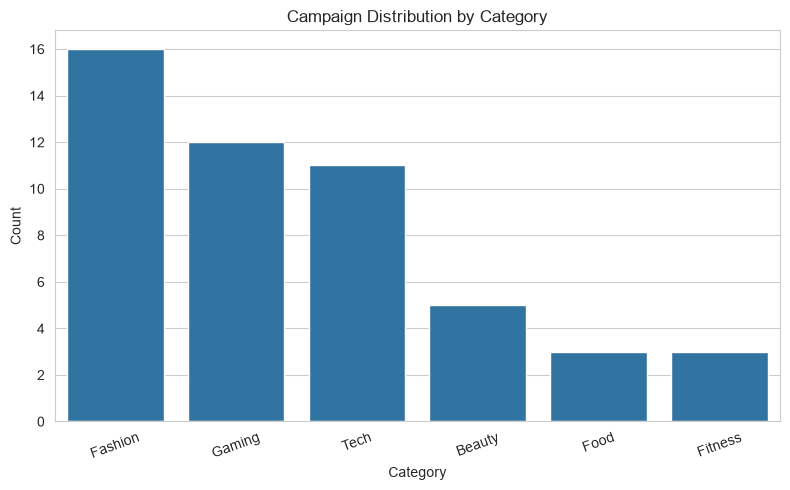

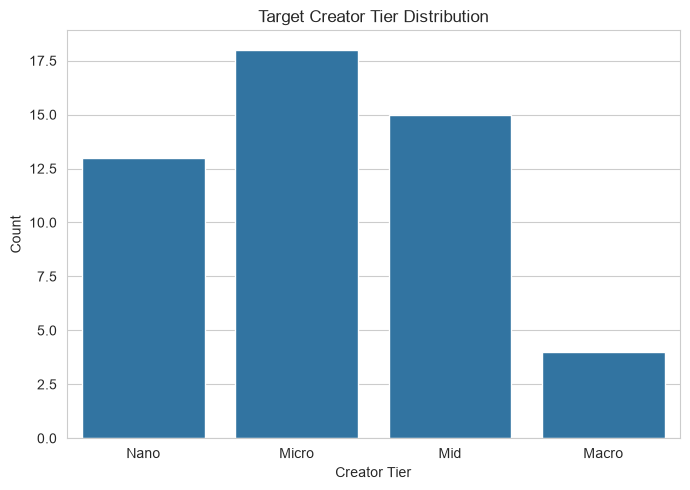

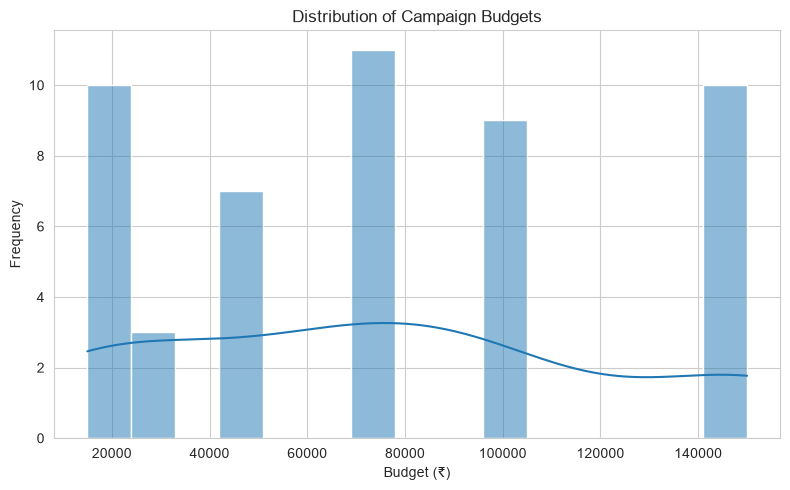

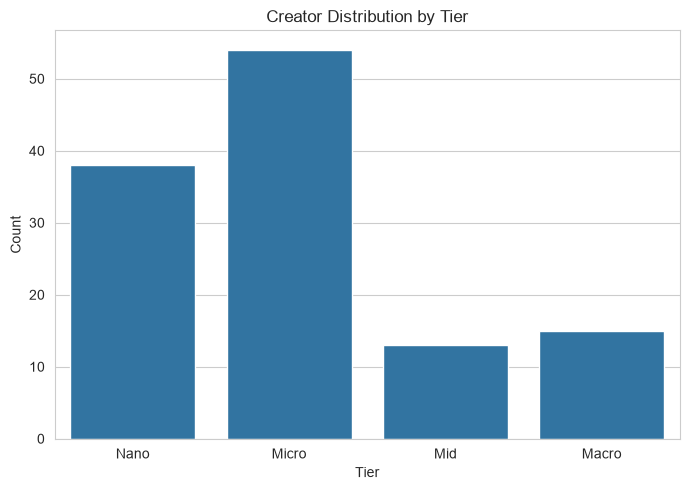

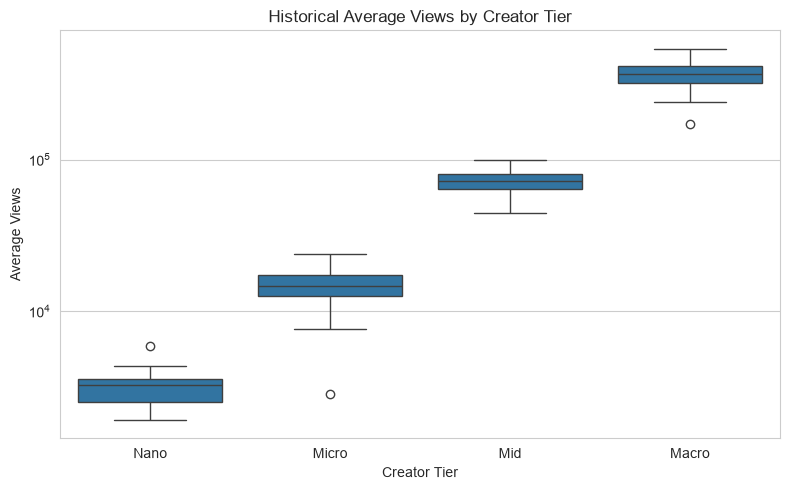

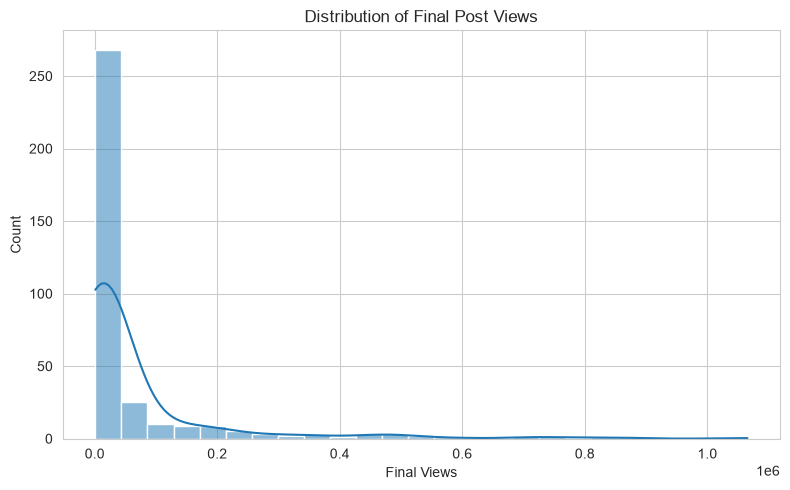

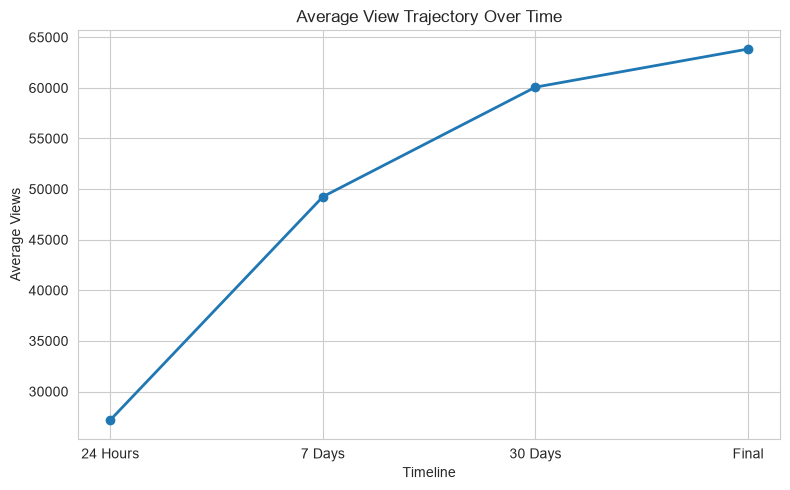

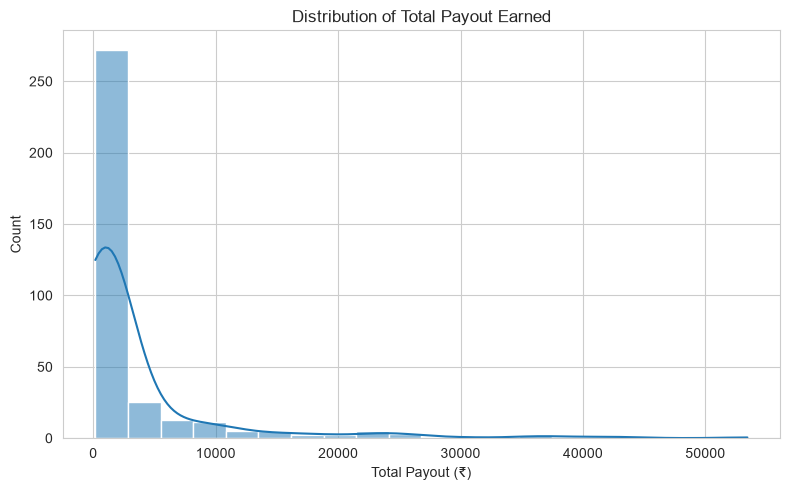

In [4]:
# Campaign Category Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=campaigns, x="category", order=campaigns["category"].value_counts().index)
plt.title("Campaign Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Target Creator Tier Distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=campaigns, x="target_creator_tier", order=["Nano", "Micro", "Mid", "Macro"])
plt.title("Target Creator Tier Distribution")
plt.xlabel("Creator Tier")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Campaign Budget Spread
plt.figure(figsize=(8, 5))
sns.histplot(campaigns["total_budget"], bins=15, kde=True)
plt.title("Distribution of Campaign Budgets")
plt.xlabel("Budget (₹)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Creator Tier Counts
plt.figure(figsize=(7, 5))
sns.countplot(data=creators, x="tier", order=["Nano", "Micro", "Mid", "Macro"])
plt.title("Creator Distribution by Tier")
plt.xlabel("Tier")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Average Views by Tier
plt.figure(figsize=(8, 5))
sns.boxplot(data=creators, x="tier", y="historical_avg_views_per_post", order=["Nano", "Micro", "Mid", "Macro"])
plt.title("Historical Average Views by Creator Tier")
plt.xlabel("Creator Tier")
plt.ylabel("Average Views")
plt.yscale("log")
plt.tight_layout()
plt.show()

# Post Final Views Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=posts, x="views_final", bins=25, kde=True)
plt.title("Distribution of Final Post Views")
plt.xlabel("Final Views")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Average View Growth Over Time
growth_data = pd.DataFrame({
    "Timeline": ["24 Hours", "7 Days", "30 Days", "Final"],
    "Avg Views": [posts["views_at_24h"].mean(), posts["views_at_7d"].mean(), posts["views_at_30d"].mean(), posts["views_final"].mean()]
})

plt.figure(figsize=(8, 5))
plt.plot(growth_data["Timeline"], growth_data["Avg Views"], marker="o", linewidth=2)
plt.title("Average View Trajectory Over Time")
plt.xlabel("Timeline")
plt.ylabel("Average Views")
plt.grid(True)
plt.tight_layout()
plt.show()

# Payout Earned Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=posts, x="total_payout_earned", bins=20, kde=True)
plt.title("Distribution of Total Payout Earned")
plt.xlabel("Total Payout (₹)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



## 5. Milestone Optimization Engine

Posts, creators, and campaigns are merged to analyze historical view performance per category and tier.
Milestone thresholds are calculated at the **20th, 40th, 60th, 80th, and 90th percentiles**.



In [5]:
analysis_df = posts.merge(creators, on="creator_id", how="left").merge(campaigns, on="campaign_id", how="left")

milestone_ladders = (
    analysis_df
    .groupby(["category", "target_creator_tier"])["views_final"]
    .quantile([0.20, 0.40, 0.60, 0.80, 0.90])
    .unstack()
    .reset_index()
)

milestone_ladders.columns = [
    "category",
    "target_creator_tier",
    "Milestone_1",
    "Milestone_2",
    "Milestone_3",
    "Milestone_4",
    "Milestone_5"
]

display(milestone_ladders.head())

def recommend_milestones(category, creator_tier, total_budget):
    match = milestone_ladders[
        (milestone_ladders["category"] == category) &
        (milestone_ladders["target_creator_tier"] == creator_tier)
    ]
    
    if match.empty:
        cat_matches = milestone_ladders[milestone_ladders["category"] == category]
        if not cat_matches.empty:
            match = cat_matches[["Milestone_1", "Milestone_2", "Milestone_3", "Milestone_4", "Milestone_5"]].mean().to_frame().T
            
    if match.empty:
        match = milestone_ladders[["Milestone_1", "Milestone_2", "Milestone_3", "Milestone_4", "Milestone_5"]].mean().to_frame().T

    row = match.iloc[0]
    payout_percents = [0.10, 0.15, 0.20, 0.25, 0.30]

    ladder = pd.DataFrame({
        "Milestone": [f"Milestone {i}" for i in range(1, 6)],
        "View Threshold": [
            int(round(row["Milestone_1"])),
            int(round(row["Milestone_2"])),
            int(round(row["Milestone_3"])),
            int(round(row["Milestone_4"])),
            int(round(row["Milestone_5"]))
        ],
        "Payout": [int(round(total_budget * p)) for p in payout_percents]
    })

    return ladder

recommended_list = []
for _, row in campaigns.iterrows():
    rec = recommend_milestones(row["category"], row["target_creator_tier"], row["total_budget"])
    rec["campaign_id"] = row["campaign_id"]
    recommended_list.append(rec)

recommended_campaigns = pd.concat(recommended_list, ignore_index=True)
display(recommended_campaigns.head())



,category,target_creator_tier,Milestone_1,Milestone_2,Milestone_3,Milestone_4,Milestone_5
0,Beauty,Macro,16664.4,23610.8,36028.4,84895.6,207337.4
1,Beauty,Micro,2975.4,6777.8,12496.0,99538.8,330431.4
2,Beauty,Mid,5148.6,10339.4,25656.0,60480.6,160519.2
3,Fashion,Macro,5362.0,5436.0,12219.0,22383.0,53012.5
4,Fashion,Micro,2997.6,7974.8,14223.4,57650.4,291206.8


,Milestone,View Threshold,Payout,campaign_id
0,Milestone 1,2653,1500,CMP_001
1,Milestone 2,12745,2250,CMP_001
2,Milestone 3,17781,3000,CMP_001
3,Milestone 4,51482,3750,CMP_001
4,Milestone 5,60269,4500,CMP_001


## 6. Backtesting & Model Validation


In [6]:
recommended_comparison = recommended_campaigns.copy()
recommended_comparison["milestone_rank"] = recommended_comparison["Milestone"].str.extract(r"(\d)").astype(int)
recommended_comparison.rename(
    columns={"View Threshold": "recommended_threshold", "Payout": "recommended_payout"},
    inplace=True
)

backtest = historical_ladders.merge(
    recommended_comparison[["campaign_id", "milestone_rank", "recommended_threshold", "recommended_payout"]],
    on=["campaign_id", "milestone_rank"],
    how="inner"
)

backtest["threshold_difference"] = backtest["recommended_threshold"] - backtest["view_threshold"]
backtest["payout_difference"] = backtest["recommended_payout"] - backtest["payout_amount"]

budget_check = recommended_campaigns.groupby("campaign_id")["Payout"].sum().reset_index(name="recommended_total_payout")
budget_check = budget_check.merge(campaigns[["campaign_id", "total_budget"]], on="campaign_id", how="left")
budget_check["within_budget"] = budget_check["recommended_total_payout"] <= budget_check["total_budget"]

post_eval = []
for _, post in posts.iterrows():
    cid = post["campaign_id"]
    v = post["views_final"]
    
    rec_l = recommended_comparison[recommended_comparison["campaign_id"] == cid].sort_values("milestone_rank")
    rec_hits = sum(v >= row["recommended_threshold"] for _, row in rec_l.iterrows())
    
    post_eval.append({"post_id": post["post_id"], "views_final": v, "rec_hits": rec_hits})

post_eval_df = pd.DataFrame(post_eval)

summary_table = pd.DataFrame({
    "Metric": [
        "Average Threshold Difference",
        "Max Threshold Difference",
        "Average Payout Difference",
        "Max Payout Difference",
        "Campaigns Within Budget",
        "Avg Milestones Reached per Post"
    ],
    "Value": [
        round(backtest["threshold_difference"].abs().mean(), 2),
        round(backtest["threshold_difference"].abs().max(), 2),
        round(backtest["payout_difference"].abs().mean(), 2),
        round(backtest["payout_difference"].abs().max(), 2),
        f"{budget_check['within_budget'].sum()} / {len(budget_check)}",
        f"{post_eval_df['rec_hits'].mean():.2f} / 5"
    ]
})

print("Backtesting Summary:")
display(summary_table)



Backtesting Summary:


,Metric,Value
0,Average Threshold Difference,96940.88
1,Max Threshold Difference,1066988
2,Average Payout Difference,0.0
3,Max Payout Difference,0
4,Campaigns Within Budget,50 / 50
5,Avg Milestones Reached per Post,2.16 / 5


## 7. Test Campaign Recommendation Engine


In [7]:
cat_options = sorted(campaigns["category"].unique())
tier_options = sorted(campaigns["target_creator_tier"].unique())

print("Categories:", ", ".join(cat_options))
print("Tiers     :", ", ".join(tier_options))

try:
    user_cat = input(f"\nEnter Category ({cat_options[0]}): ").strip() or cat_options[0]
    user_tier = input(f"Enter Creator Tier ({tier_options[1]}): ").strip() or tier_options[1]
    user_budget = float(input("Enter Campaign Budget (50000): ") or 50000)
except Exception:
    user_cat, user_tier, user_budget = "Gaming", "Micro", 50000.0

result = recommend_milestones(user_cat, user_tier, user_budget)

formatted_result = result.copy()
formatted_result["View Threshold"] = formatted_result["View Threshold"].apply(lambda x: f"{int(x):,}")
formatted_result["Payout"] = formatted_result["Payout"].apply(lambda x: f"₹{int(x):,}")

print(f"\nRecommended Milestone Ladder for Category: {user_cat} | Tier: {user_tier} | Budget: ₹{user_budget:,.2f}")
display(formatted_result)



Categories: Beauty, Fashion, Fitness, Food, Gaming, Tech
Tiers     : Macro, Micro, Mid, Nano

Recommended Milestone Ladder for Category: games | Tier: micro | Budget: ₹400,000.00


,Milestone,View Threshold,Payout
0,Milestone 1,"10,709","₹40,000"
1,Milestone 2,"19,840","₹60,000"
2,Milestone 3,"27,851","₹80,000"
3,Milestone 4,"73,617","₹100,000"
4,Milestone 5,"188,469","₹120,000"
